<a href="https://colab.research.google.com/github/Sid-DudeD017/steam-indie-predictor/blob/main/Indie_Game_Success_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Steam Indie Game Success Predictor



**Author:** Siddharth Bhakta

**Live App:** https://steam-indie-predictor-jju8srpp8q6f55td75rzbq.streamlit.app/

**GitHub Repo:** https://github.com/Sid-DudeD017/steam-indie-predictor

## Executive Summary
The global success rate for new Indie games on Steam is roughly **6%**. This project aims to analyze historical Steam metadata to identify the mathematical patterns behind breakout hits.

In this notebook, we will:
1. **Ingest & Clean** raw tabular Steam store data.
2. **Build a Native ML Pipeline** using `imblearn` and `sklearn` to handle severe class imbalance seamlessly.
3. **Train & Evaluate** a Random Forest Classifier.
4. **Deploy** the raw pipeline object for web server inference.

##Importing Libraries

In [15]:
# Standard Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# Machine Learning & NLP
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

# Handling Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

#Testing Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

#HyperParameter Tuning
from sklearn.model_selection import RandomizedSearchCV

# Exporting
import joblib

import warnings
warnings.filterwarnings('ignore')

## 1. Data Ingestion & Target Engineering
Scikit-Learn pipelines expect an `X` (features) and `y` (target) to begin training. We will write a standard procedural function to load our raw CSV, filter out non-Indie games, and create our target variable (`is_hit`).

In [4]:
def load_and_prepare_data(csv_path):
    print("Loading raw Steam data...")
    raw_columns = [
        'price', 'required_age', 'dlc_count', 'achievements',
        'windows', 'mac', 'linux', 'tags',
        'pct_pos_total', 'num_reviews_total', 'release_date'
    ]
    df = pd.read_csv(csv_path, usecols=raw_columns, engine='python', on_bad_lines='skip')

    # Isolate true Indie games
    df = df.dropna(subset=['tags'])
    df = df[df['tags'].str.contains('Indie', case=False, na=False)].copy()

    # Engineer Target Variable
    df['pct_pos_total'] = pd.to_numeric(df['pct_pos_total'], errors='coerce')
    df['num_reviews_total'] = pd.to_numeric(df['num_reviews_total'], errors='coerce')
    df = df.dropna(subset=['pct_pos_total', 'num_reviews_total'])

    # Hit criteria: 90% positive + 500 reviews
    df['is_hit'] = ((df['pct_pos_total'] >= 90) & (df['num_reviews_total'] >= 500)).astype(int)

    # Parse dates
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['release_year'] = df['release_date'].dt.year.fillna(2024)
    df['release_month'] = df['release_date'].dt.month.fillna(1)

    # Define final features
    features = [
        'price', 'required_age', 'dlc_count', 'achievements',
        'windows', 'mac', 'linux', 'release_year', 'release_month', 'tags'
    ]

    return df[features], df['is_hit']

# Load the data into X and y
X, y = load_and_prepare_data('games_march2025_cleaned.csv')

Loading raw Steam data...


##Understanding Data

In [5]:
X.head(5)

,price,required_age,dlc_count,achievements,windows,mac,linux,release_year,release_month,tags
6,9.99,0,2,115,True,True,True,2011,5,"{'Open World Survival Craft': 16365, 'Sandbox'..."
7,39.99,0,4,92,True,True,False,2018,2,"{'Survival': 18592, 'Crafting': 11822, 'Multip..."
8,5.99,0,0,29,True,True,True,2006,11,"{'Sandbox': 18706, 'Moddable': 14479, 'Multipl..."
13,14.99,0,1,49,True,True,True,2016,2,"{'Farming Sim': 7706, 'Pixel Graphics': 7169, ..."
17,19.99,0,98,98,True,True,True,2012,10,"{'Driving': 12858, 'Transportation': 12635, 'S..."


In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43408 entries, 6 to 89617
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          43408 non-null  float64
 1   required_age   43408 non-null  int64  
 2   dlc_count      43408 non-null  int64  
 3   achievements   43408 non-null  int64  
 4   windows        43408 non-null  bool   
 5   mac            43408 non-null  bool   
 6   linux          43408 non-null  bool   
 7   release_year   43408 non-null  int32  
 8   release_month  43408 non-null  int32  
 9   tags           43408 non-null  object 
dtypes: bool(3), float64(1), int32(2), int64(3), object(1)
memory usage: 2.4+ MB


In [ ]:
game_data.describe()


,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,score_rank,positive,...,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
count,5.066800e+04,50668.000000,50668.000000,50668.000000,50668.000000,50668.000000,5.066800e+04,50668.000000,38.000000,5.066800e+04,...,5.066800e+04,50668.000000,5.066800e+04,50668.000000,50668.000000,5.066800e+04,50668.000000,5.066800e+04,50668.000000,50668.000000
mean,1.432962e+06,0.275420,7.899469,0.888450,5.083721,29.855589,1.763943e+03,0.057314,99.157895,2.216766e+03,...,1.970526e+02,8.615004,1.968895e+02,8.991237,5.950955,1.685058e+02,77.139792,2.326949e+03,9.894509,27.863622
std,8.758769e+05,2.111977,10.925999,19.460056,18.837694,214.474515,2.907649e+04,2.141434,0.678883,4.211252e+04,...,9.054228e+03,238.648049,1.170582e+04,246.790682,18.778004,7.579918e+03,17.313362,4.708646e+04,28.651861,588.579719
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,1.100000e+01,-1.000000,-1.000000
25%,6.697650e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,99.000000,1.300000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,67.000000,2.300000e+01,-1.000000,-1.000000
50%,1.287835e+06,0.000000,4.990000,0.000000,0.000000,11.000000,0.000000e+00,0.000000,99.000000,4.100000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,81.000000,6.100000e+01,-1.000000,-1.000000
75%,2.160270e+06,0.000000,9.990000,0.000000,0.000000,27.000000,1.760000e+02,0.000000,100.000000,2.010000e+02,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,1.000000e+00,91.000000,2.630000e+02,-1.000000,-1.000000
max,3.530080e+06,20.000000,199.990000,3427.000000,97.000000,9821.000000,4.401572e+06,100.000000,100.000000,7.480813e+06,...,1.462997e+06,18568.000000,1.462997e+06,18568.000000,100.000000,1.212356e+06,100.000000,8.632939e+06,100.000000,96473.000000


In [9]:
X.isnull().sum()

,0
price,0
required_age,0
dlc_count,0
achievements,0
windows,0
mac,0
linux,0
release_year,0
release_month,0
tags,0


## 2. The Native Scikit-Learn Pipeline
Here is where the magic happens. We create a custom `clean_tags` function and wrap it in a `FunctionTransformer`.

We then chain this transformer directly into a `ColumnTransformer` alongside the `CountVectorizer`. This means the pipeline itself knows how to clean messy user input before vectorizing it!

In [10]:
# 1. Custom Text Cleaner designed to work inside the Pipeline
def clean_tags_series(X_col):
    """Takes a pandas Series of tags, cleans them, and returns a Series."""
    def _clean(tag_string):
        if pd.isna(tag_string): return "indie"
        clean_str = re.sub(r'[^a-zA-Z\s,]', '', str(tag_string))
        tags = [t.strip().lower() for t in clean_str.split(',') if t.strip()]
        return ",".join(tags)
    return X_col.apply(_clean)

# Wrap it so Scikit-Learn understands it
tag_cleaner = FunctionTransformer(clean_tags_series)

# 2. Sub-pipeline strictly for the text column
text_pipeline = ImbPipeline(steps=[
    ('cleaner', tag_cleaner),
    ('vectorizer', CountVectorizer(token_pattern=r'[^,]+', max_features=100))
])

# 3. Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        # Apply the text_pipeline only to the 'tags' column
        ('text_processing', text_pipeline, 'tags')
    ],
    remainder='passthrough'
)

# 4. The Master Pipeline
master_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=30, max_depth=15, random_state=42, n_jobs=-1))
])

# 5. Train and Save
print("Splitting Data and Training the Forest...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

master_pipeline.fit(X_train, y_train)

print("Saving production model to 'indie_model_native.pkl'...")
joblib.dump(master_pipeline, 'indie_model_native.pkl')
print("Native Pipeline successfully saved!")

Splitting Data and Training the Forest...
Saving production model to 'indie_model_native.pkl'...
Native Pipeline successfully saved!


## 3. Model Evaluation & Performance Metrics
To ensure our model generalizes well to new data, we evaluate it against our holdout test set (`X_test` and `y_test`).

Because our dataset is heavily imbalanced (most games are not hits), **Accuracy is a dangerous metric**. If a model simply guesses "0" every time, it might achieve 94% accuracy but be completely useless. Therefore, we will focus heavily on:
* **Precision:** When the model calls a game a "Hit", how often is it actually right?
* **Recall:** Out of all the true "Hits" in reality, how many did the model successfully find?
* **Confusion Matrix:** A visual grid showing exactly where the model's predictions align with reality.

Running predictions on the test set...

 Accuracy:  96.11% (Treat with caution due to imbalance)
 Precision: 47.89% (Trustworthiness of a 'Hit' prediction)
 Recall:    10.15% (Ability to find the 'Hits')
 F1 Score:  16.75% (Harmonic balance of Precision and Recall)

--------------------------------------------------
Detailed Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

    Flop (0)       0.97      1.00      0.98      8347
     Hit (1)       0.48      0.10      0.17       335

    accuracy                           0.96      8682
   macro avg       0.72      0.55      0.57      8682
weighted avg       0.95      0.96      0.95      8682



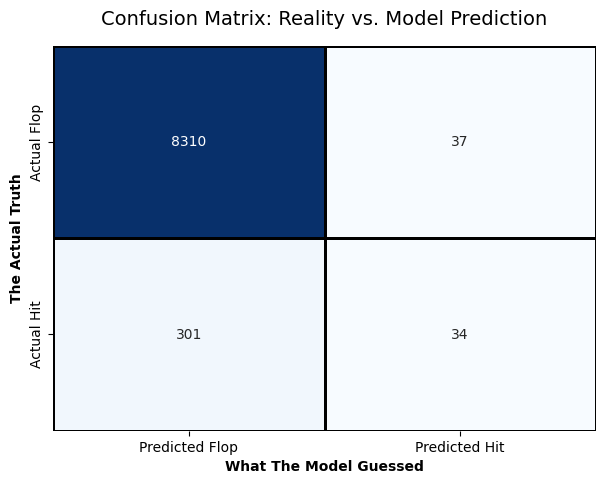

In [13]:
# 1. Generate predictions on the unseen test data
print("Running predictions on the test set...\n")
y_pred = master_pipeline.predict(X_test)

# 2. Calculate individual core metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f" Accuracy:  {acc * 100:.2f}% (Treat with caution due to imbalance)")
print(f" Precision: {prec * 100:.2f}% (Trustworthiness of a 'Hit' prediction)")
print(f" Recall:    {rec * 100:.2f}% (Ability to find the 'Hits')")
print(f" F1 Score:  {f1 * 100:.2f}% (Harmonic balance of Precision and Recall)\n")

# 3. Print the comprehensive classification report
print("-" * 50)
print("Detailed Classification Report:")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Flop (0)', 'Hit (1)']))

# 4. Plot a visually appealing Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Flop', 'Predicted Hit'],
            yticklabels=['Actual Flop', 'Actual Hit'],
            cbar=False, linewidths=1, linecolor='black')

plt.title("Confusion Matrix: Reality vs. Model Prediction", pad=15, fontsize=14)
plt.ylabel('The Actual Truth', weight='bold')
plt.xlabel('What The Model Guessed', weight='bold')
plt.show()

##4. Hyperparameter Tuning

In [17]:
print("1. Setting up Hyperparameter Grid...")
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    # CRITICAL FIX: Force the model to pay heavy attention to the minority class
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

print("2. Configuring Randomized Search...")
random_search = RandomizedSearchCV(
    estimator=master_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=3
)

print("3. Beginning Tuning (This might take a few minutes)...")
random_search.fit(X_train, y_train)

print("\n✅ Tuning Complete!")
print("-" * 50)
print("🏆 Best Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f" - {param.replace('classifier__', '')}: {value}")

# 4. Save the optimized brain to a variable in memory so we can use it right now!
best_master_pipeline = random_search.best_estimator_

1. Setting up Hyperparameter Grid...
2. Configuring Randomized Search...
3. Beginning Tuning (This might take a few minutes)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV 1/3] END classifier__class_weight=balanced, classifier__max_depth=10, classifier__min_samples_split=5, classifier__n_estimators=100;, score=0.226 total time=  17.2s
[CV 2/3] END classifier__class_weight=balanced, classifier__max_depth=10, classifier__min_samples_split=5, classifier__n_estimators=100;, score=0.278 total time=  13.8s
[CV 3/3] END classifier__class_weight=balanced, classifier__max_depth=10, classifier__min_samples_split=5, classifier__n_estimators=100;, score=0.224 total time=  13.8s
[CV 1/3] END classifier__class_weight=balanced_subsample, classifier__max_depth=20, classifier__min_samples_split=10, classifier__n_estimators=200;, score=0.055 total time=  54.9s
[CV 2/3] END classifier__class_weight=balanced_subsample, classifier__max_depth=20, classifier__min_samples_split=10, classi

Running predictions using the OPTIMIZED model...

 Accuracy:  95.65%
 Precision: 38.25%
 Recall:    20.90%
 F1 Score:  27.03%

--------------------------------------------------
Optimized Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

    Flop (0)       0.97      0.99      0.98      8347
     Hit (1)       0.38      0.21      0.27       335

    accuracy                           0.96      8682
   macro avg       0.68      0.60      0.62      8682
weighted avg       0.95      0.96      0.95      8682



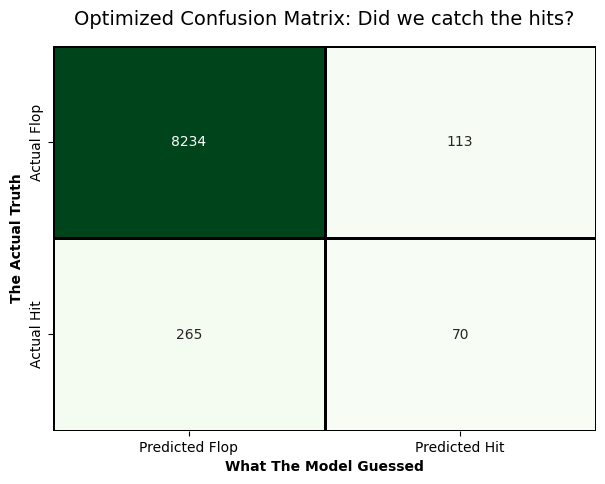

In [18]:
print("Running predictions using the OPTIMIZED model...\n")
y_pred_tuned = best_master_pipeline.predict(X_test)

# Calculate individual core metrics
acc = accuracy_score(y_test, y_pred_tuned)
prec = precision_score(y_test, y_pred_tuned)
rec = recall_score(y_test, y_pred_tuned)
f1 = f1_score(y_test, y_pred_tuned)

print(f" Accuracy:  {acc * 100:.2f}%")
print(f" Precision: {prec * 100:.2f}%")
print(f" Recall:    {rec * 100:.2f}%")
print(f" F1 Score:  {f1 * 100:.2f}%\n")

# Print the comprehensive classification report
print("-" * 50)
print("Optimized Classification Report:")
print("-" * 50)
print(classification_report(y_test, y_pred_tuned, target_names=['Flop (0)', 'Hit (1)']))

# Plot the new Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', # Changed to Green to distinguish from the old one
            xticklabels=['Predicted Flop', 'Predicted Hit'],
            yticklabels=['Actual Flop', 'Actual Hit'],
            cbar=False, linewidths=1, linecolor='black')

plt.title("Optimized Confusion Matrix: Did we catch the hits?", pad=15, fontsize=14)
plt.ylabel('The Actual Truth', weight='bold')
plt.xlabel('What The Model Guessed', weight='bold')
plt.show()

## 4. Deployment Simulation
Because we used a native pipeline, the backend web developer does not need to import any custom classes. They simply load the `.pkl` file using `joblib` and pass the raw JSON payload from the website directly into the model.

In [23]:
save_name = 'indie_model_optimized.pkl'
joblib.dump(best_master_pipeline, save_name)
print(f"Optimized model successfully saved as '{save_name}'")
print("-" * 50)

production_model = joblib.load(save_name)

# 3. A user submits a form on the live site
incoming_web_request = {
    'price': [19.99],
    'required_age': [0],
    'dlc_count': [0],
    'achievements': [45],
    'windows': [True],
    'mac': [True],
    'linux': [False],
    'release_year': [2027],
    'release_month': [11],
    'tags': ['Indie, RPG, Story Rich, Masterpiece, Singleplayer']
}

df_input = pd.DataFrame(incoming_web_request)

# 4. The server generates the prediction
probability = production_model.predict_proba(df_input)[0][1]

print(f" Web Request Processed.")
print(f" Optimized Model calculates a {probability * 100:.2f}% chance of becoming a Hit.")

if probability >= 0.20:
    print(" RESULT: GREEN LIGHT!")
else:
    print(" RESULT: HIGH RISK.")

Optimized model successfully saved as 'indie_model_optimized.pkl'
--------------------------------------------------
 Web Request Processed.
 Optimized Model calculates a 19.30% chance of becoming a Hit.
 RESULT: HIGH RISK.


In [22]:
import sys
import pandas as pd
import sklearn
import imblearn
import joblib
import numpy as np

print("=== MY EXACT COLAB ENVIRONMENT ===")
print(f"Python Version: {sys.version.split()[0]}")
print(f"pandas=={pd.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"imbalanced-learn=={imblearn.__version__}")
print(f"joblib=={joblib.__version__}")
print(f"numpy=={np.__version__}")

=== MY EXACT COLAB ENVIRONMENT ===
Python Version: 3.12.13
pandas==2.2.2
scikit-learn==1.6.1
imbalanced-learn==0.14.1
joblib==1.5.3
numpy==2.0.2
